### Imports and paths

In [1]:
from pathlib import Path
import pandas as pd

### Paths

In [2]:
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
INTERIM_DIR = REPO_ROOT / "data" / "interim"

GOLD_PATH = PROCESSED_DIR / "gold_nbhd_day_weather.parquet"
ONT511_PATH = INTERIM_DIR / "ontario511_nbhd_daily.parquet"

print("GOLD_PATH:", GOLD_PATH)
print("ONT511_PATH:", ONT511_PATH)

GOLD_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\gold_nbhd_day_weather.parquet
ONT511_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\ontario511_nbhd_daily.parquet


### Load files

In [3]:
gold = pd.read_parquet(GOLD_PATH)
ont511 = pd.read_parquet(ONT511_PATH)

print("gold shape:", gold.shape)
print("ont511 shape:", ont511.shape)

gold.head(2)

gold shape: (692514, 22)
ont511 shape: (2410, 8)


,AREA_ID,AREA_NAME,date,collisions,area_id,nbhd_id,area_name,ksi_collisions,ksi_fatal_collisions,ksi_serious_collisions,...,ksi_weighted_score,tavg,tmin,tmax,prcp,snow,wspd,freeze_day,snow_day,rain_day
0,2502366,South Eglinton-Davisville,2014-01-01,0,2502366,174,South Eglinton-Davisville,0,0,0,...,0,-11.1,-14.8,-8.8,0.0,0.21,18.0,1,1,0
1,2502366,South Eglinton-Davisville,2014-01-02,0,2502366,174,South Eglinton-Davisville,0,0,0,...,0,-17.3,-19.3,-14.9,2.5,2.24,23.1,1,1,1


### Align date types

In [4]:
# Gold may be datetime64[ns] or object; normalize both sides to datetime.date
gold["date"] = pd.to_datetime(gold["date"]).dt.date
ont511["date"] = pd.to_datetime(ont511["date"]).dt.date

print("gold date dtype:", gold["date"].dtype)
print("ont511 date dtype:", ont511["date"].dtype)

gold date dtype: object
ont511 date dtype: object


### Validate join keys

In [5]:
if "nbhd_id" not in gold.columns:
    raise ValueError("gold table is missing nbhd_id")

if "nbhd_id" not in ont511.columns:
    raise ValueError("ont511 table is missing nbhd_id")

print("Gold nbhd coverage:", gold["nbhd_id"].nunique())
print("511 nbhd coverage:", ont511["nbhd_id"].nunique())

Gold nbhd coverage: 158
511 nbhd coverage: 13


### Prefix 511 features

In [6]:
rename_map = {
    "events_count": "road_events_count",
    "events_severity_weighted": "road_events_severity_weighted",
    "events_full_closure_count": "road_events_full_closure_count",
    "construction_count": "road_construction_count",
    "construction_severity_weighted": "road_construction_severity_weighted",
    "construction_full_closure_count": "road_construction_full_closure_count",
}

ont511 = ont511.rename(columns=rename_map)

print(ont511.columns.tolist())

['date', 'nbhd_id', 'road_events_count', 'road_events_severity_weighted', 'road_events_full_closure_count', 'road_construction_count', 'road_construction_severity_weighted', 'road_construction_full_closure_count']


### merge

In [7]:
before_rows = len(gold)

merged = gold.merge(
    ont511,
    on=["date", "nbhd_id"],
    how="left"
)

assert len(merged) == before_rows, "Row count changed after merge"

print("merged shape:", merged.shape)

merged shape: (692514, 28)


### Fill missing 511 values with 0

In [8]:
road_cols = [
    "road_events_count",
    "road_events_severity_weighted",
    "road_events_full_closure_count",
    "road_construction_count",
    "road_construction_severity_weighted",
    "road_construction_full_closure_count",
]

for c in road_cols:
    if c in merged.columns:
        merged[c] = merged[c].fillna(0).astype(int)

merged[road_cols].describe()

,road_events_count,road_events_severity_weighted,road_events_full_closure_count,road_construction_count,road_construction_severity_weighted,road_construction_full_closure_count
count,692514.0,692514.0,692514.0,692514.000000,692514.000000,692514.0
mean,0.0,0.0,0.0,0.003357,0.003357,0.0
std,0.0,0.0,0.0,0.057845,0.057845,0.0
min,0.0,0.0,0.0,0.000000,0.000000,0.0
25%,0.0,0.0,0.0,0.000000,0.000000,0.0
50%,0.0,0.0,0.0,0.000000,0.000000,0.0
75%,0.0,0.0,0.0,0.000000,0.000000,0.0
max,0.0,0.0,0.0,1.000000,1.000000,0.0


### Quick sanity checks

In [9]:
print("Any nulls in road cols?")
print(merged[road_cols].isna().sum())

print("\nNon-zero counts:")
for c in road_cols:
    print(c, "->", (merged[c] > 0).sum())

print("\nDate range in merged gold:")
print(merged["date"].min(), "to", merged["date"].max())

Any nulls in road cols?
road_events_count                       0
road_events_severity_weighted           0
road_events_full_closure_count          0
road_construction_count                 0
road_construction_severity_weighted     0
road_construction_full_closure_count    0
dtype: int64

Non-zero counts:
road_events_count -> 0
road_events_severity_weighted -> 0
road_events_full_closure_count -> 0
road_construction_count -> 2325
road_construction_severity_weighted -> 2325
road_construction_full_closure_count -> 0

Date range in merged gold:
2014-01-01 to 2025-12-31


### Save

In [10]:
out_path = PROCESSED_DIR / "gold_nbhd_day_weather_511.parquet"
merged.to_parquet(out_path, index=False)

print("Saved:", out_path)

Saved: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\gold_nbhd_day_weather_511.parquet


### EDA

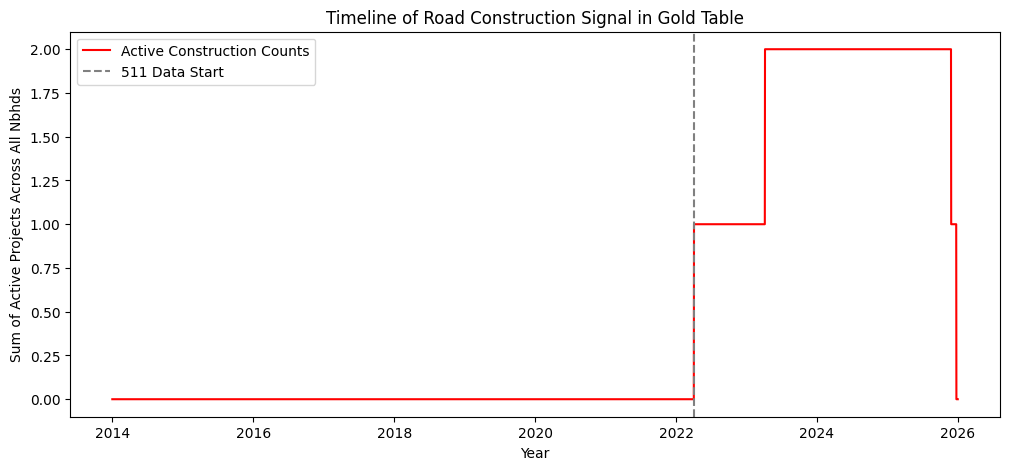

Neighborhoods with active construction signal: 2 / 158
<ArrowStringArray>
['Fenside-Parkwoods', 'West Humber-Clairville']
Length: 2, dtype: str


In [11]:
import matplotlib.pyplot as plt

#visualizing the "Onboarding" of 511 Data
plt.figure(figsize=(12, 5))
merged.groupby('date')['road_construction_count'].sum().plot(color='red', label='Active Construction Counts')
plt.title('Timeline of Road Construction Signal in Gold Table')
plt.ylabel('Sum of Active Projects Across All Nbhds')
plt.xlabel('Year')
plt.axvline(pd.to_datetime("2022-04-04").date(), color='gray', linestyle='--', label='511 Data Start')
plt.legend()
plt.show()

#checking neighborhood penetration
active_nbhds = merged[merged['road_construction_count'] > 0]['area_name'].unique()
print(f"Neighborhoods with active construction signal: {len(active_nbhds)} / 158")
print(active_nbhds)